In [6]:
pip install seaborn 


Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [10]:
data=pd.read_csv('Churn_Modelling.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
#preprocess the data
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [13]:
data


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [14]:
print("Shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())
print("\nData types:")
print(data.dtypes)

Shape: (10000, 11)

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Data types:
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [15]:
print("Shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())
print("\nData types:")
print(data.dtypes)

Shape: (10000, 11)

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Data types:
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


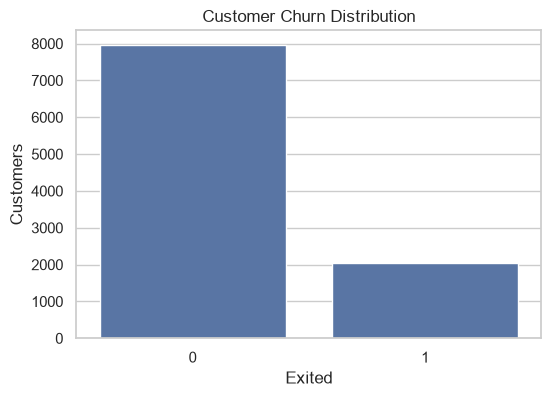

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Customers")
plt.show()

print(data["Exited"].value_counts(normalize=True))

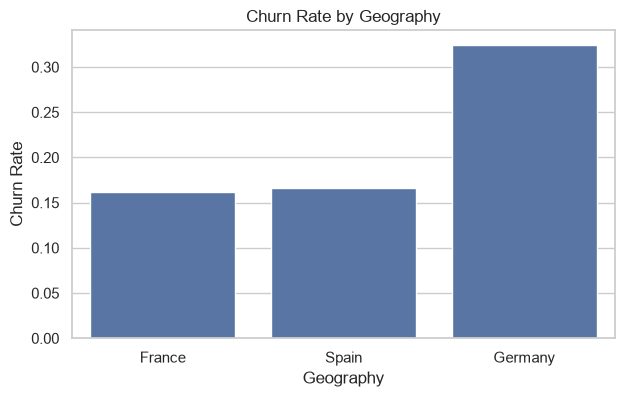

In [17]:
plt.figure(figsize=(7,4))
sns.barplot(data=data, x="Geography", y="Exited", errorbar=None)
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.show()

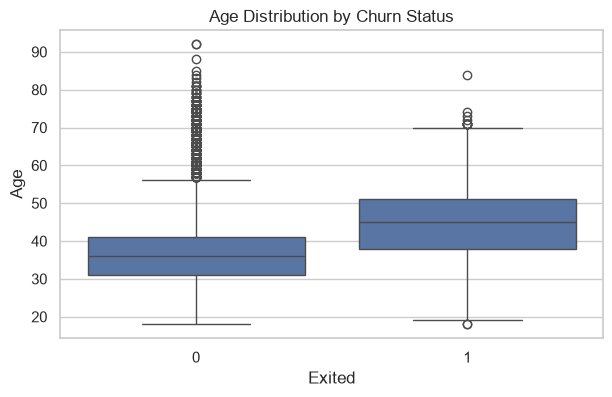

In [18]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Exited", y="Age")
plt.title("Age Distribution by Churn Status")
plt.show()

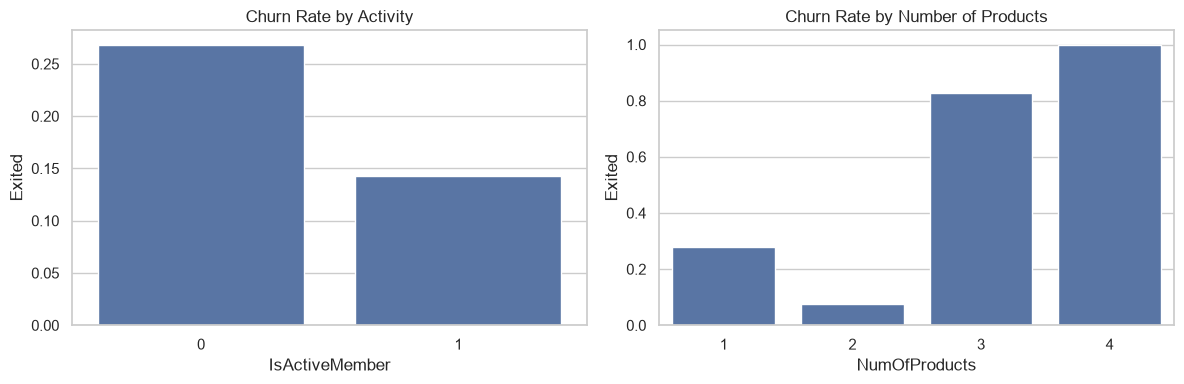

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=data, x="IsActiveMember", y="Exited", errorbar=None, ax=axes[0])
axes[0].set_title("Churn Rate by Activity")

sns.barplot(data=data, x="NumOfProducts", y="Exited", errorbar=None, ax=axes[1])
axes[1].set_title("Churn Rate by Number of Products")

plt.tight_layout()
plt.show()

In [20]:
data["BalanceSalaryRatio"] = (
    data["Balance"] / data["EstimatedSalary"]
)

data["TenureByAge"] = (
    data["Tenure"] / data["Age"]
)

data["HasZeroBalance"] = (
    data["Balance"] == 0
).astype(int)

data["IsSenior"] = (
    data["Age"] >= 50
).astype(int)

data["BalancePerProduct"] = (
    data["Balance"] / data["NumOfProducts"]
)

data["SalaryPerProduct"] = (
    data["EstimatedSalary"] / data["NumOfProducts"]
)

In [21]:
X = data.drop("Exited", axis=1)
y = data["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

In [22]:
categorical_features = [
    "Geography",
    "Gender"
]

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "BalanceSalaryRatio",
    "TenureByAge",
    "HasZeroBalance",
    "IsSenior",
    "BalancePerProduct",
    "SalaryPerProduct"
]

In [23]:
preprocessor = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ),
        categorical_features
    ),
    (
        "num",
        StandardScaler(),
        numeric_features
    )
])

In [24]:
#adding models
logistic = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

In [25]:
random_forest = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [26]:
xgboost = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [27]:
lightgbm = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1
        )
    )
])

In [28]:
models = {
    "Logistic Regression": logistic,
    "Random Forest": random_forest,
    "XGBoost": xgboost,
    "LightGBM": lightgbm
}

In [29]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    probability = model.predict_proba(X_test)[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction
        ),
        "Recall": recall_score(
            y_test,
            prediction
        ),
        "F1": f1_score(
            y_test,
            prediction
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probability
        )
    })

comparison = pd.DataFrame(results)

comparison.sort_values(
    "ROC-AUC",
    ascending=False
)


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training LightGBM...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.8625,0.755814,0.479115,0.586466,0.862107
1,Random Forest,0.8620,0.807512,0.422604,0.554839,0.854472
3,LightGBM,0.8240,0.556701,0.663391,0.605381,0.851676
0,Logistic Regression,0.7200,0.400520,0.756757,0.523810,0.792190


In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [31]:
#hyperparameter tuning for models
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train
)

best_xgb = xgb_search.best_estimator_

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print(
    "Best CV ROC-AUC:",
    xgb_search.best_score_
)

Best XGBoost parameters:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.85}
Best CV ROC-AUC: 0.8658741127408962


In [32]:
logistic_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logistic_search = RandomizedSearchCV(
    logistic_pipeline,
    logistic_params,
    n_iter=5,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

best_logistic = logistic_search.best_estimator_

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)
print("Best CV ROC-AUC:", logistic_search.best_score_)

Best Logistic Regression parameters:
{'model__C': 0.1}
Best CV ROC-AUC: 0.7773184309117701


In [33]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [6, 8, 12, None],
    "model__min_samples_leaf": [2, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", 0.5]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 8}
Best CV ROC-AUC: 0.861262050832603


In [34]:
lgbm_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMClassifier(
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_params = {
    "model__n_estimators": [200, 300, 500],
    "model__num_leaves": [15, 31, 63],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_samples": [10, 20, 40]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    lgbm_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

best_lgbm = lgbm_search.best_estimator_

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)
print("Best CV ROC-AUC:", lgbm_search.best_score_)

Best LightGBM parameters:
{'model__subsample': 0.7, 'model__num_leaves': 15, 'model__n_estimators': 500, 'model__min_child_samples': 40, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.7}
Best CV ROC-AUC: 0.8631810345657847


In [35]:
tuned_models = {
    "Logistic Regression": best_logistic,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

In [36]:
import joblib

# Save all tuned ML models
joblib.dump(tuned_models, "ml_models.joblib")

print("All ML models saved successfully.")

All ML models saved successfully.


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison_results = []

# ML models
for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    comparison_results.append({
        "Model": name,
        "Type": "Traditional ML",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# ANN
ann_prob = ann.predict(X_test_ann).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

comparison_results.append({
    "Model": "ANN",
    "Type": "Deep Learning",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1": f1_score(y_test, ann_pred),
    "ROC-AUC": roc_auc_score(y_test, ann_prob)
})

comparison = pd.DataFrame(comparison_results)

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison

63/63 [==============================] - 0s 2ms/step


,Model,Type,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,Traditional ML,0.8680,0.791837,0.476658,0.595092,0.869803
1,ANN,Deep Learning,0.8655,0.765385,0.488943,0.596702,0.867556
2,LightGBM,Traditional ML,0.8140,0.530541,0.746929,0.620408,0.867053
3,Random Forest,Traditional ML,0.8165,0.536232,0.727273,0.617310,0.864138
4,Logistic Regression,Traditional ML,0.7185,0.398438,0.751843,0.520851,0.791980


In [58]:
comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved as model_comparison.csv")

Model comparison saved as model_comparison.csv


In [59]:
ann.save("keras_ann.keras")
joblib.dump(ann_preprocessor, "ann_preprocessor.joblib")

print("ANN model and preprocessor saved successfully.")

ANN model and preprocessor saved successfully.


In [37]:
cv_scores = {
    "Logistic Regression": logistic_search.best_score_,
    "Random Forest": rf_search.best_score_,
    "XGBoost": xgb_search.best_score_,
    "LightGBM": lgbm_search.best_score_
}

cv_results = pd.DataFrame(
    list(cv_scores.items()),
    columns=["Model", "CV ROC-AUC"]
).sort_values(
    "CV ROC-AUC",
    ascending=False
)

cv_results

,Model,CV ROC-AUC
2,XGBoost,0.865874
3,LightGBM,0.863181
1,Random Forest,0.861262
0,Logistic Regression,0.777318


In [38]:
ann_preprocessor = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_features
    ),
    (
        "num",
        StandardScaler(),
        numeric_features
    )
])

X_train_ann = ann_preprocessor.fit_transform(
    X_train
)

X_test_ann = ann_preprocessor.transform(
    X_test
)

In [39]:
X_ann_train, X_ann_val, y_ann_train, y_ann_val = train_test_split(
    X_train_ann,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

In [40]:
X_ann_train, X_ann_val, y_ann_train, y_ann_val = train_test_split(
    X_train_ann,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

In [41]:
ann = Sequential([
    Input(shape=(X_ann_train.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = ann.fit(
    X_ann_train,
    y_ann_train,
    validation_data=(
        X_ann_val,
        y_ann_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


200/200 [==============================] - 2s 3ms/step - loss: 0.4821 - accuracy: 0.7947 - val_loss: 0.4400 - val_accuracy: 0.8144
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4312 - accuracy: 0.8186 - val_loss: 0.4121 - val_accuracy: 0.8275
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4118 - accuracy: 0.8297 - val_loss: 0.3921 - val_accuracy: 0.8400
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3923 - accuracy: 0.8403 - val_loss: 0.3780 - val_accuracy: 0.8456
Epoch 5/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3835 - accuracy: 0.8420 - val_loss: 0.3701 - val_accuracy: 0.8444
Epoch 6/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3710 - accuracy: 0.8511 - val_loss: 0.3647 - val_accuracy: 0.8512
Epoch 7/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3663 - accuracy: 0.8500 - val_loss: 0.3589 - val_accuracy: 0.8

In [42]:
ann_probability = ann.predict(
    X_test_ann,
    verbose=0
).ravel()

ann_prediction = (
    ann_probability >= 0.5
).astype(int)

ann_results = {
    "Model": "Keras ANN",
    "Accuracy": accuracy_score(
        y_test,
        ann_prediction
    ),
    "Precision": precision_score(
        y_test,
        ann_prediction
    ),
    "Recall": recall_score(
        y_test,
        ann_prediction
    ),
    "F1": f1_score(
        y_test,
        ann_prediction
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        ann_probability
    )
}

comparison = pd.concat(
    [
        comparison,
        pd.DataFrame([ann_results])
    ],
    ignore_index=True
)

comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,Keras ANN,0.8655,0.765385,0.488943,0.596702,0.867556
2,XGBoost,0.8625,0.755814,0.479115,0.586466,0.862107
1,Random Forest,0.8620,0.807512,0.422604,0.554839,0.854472
3,LightGBM,0.8240,0.556701,0.663391,0.605381,0.851676
0,Logistic Regression,0.7200,0.400520,0.756757,0.523810,0.792190


In [60]:
tuned_models = {
    "Logistic Regression": best_logistic,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

print("Tuned ML models ready:")
for name in tuned_models:
    print(name)

Tuned ML models ready:
Logistic Regression
Random Forest
XGBoost
LightGBM


In [61]:
comparison_results = []

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    comparison_results.append({
        "Model": name,
        "Type": "Traditional ML",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ann_prob = ann.predict(X_test_ann, verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

comparison_results.append({
    "Model": "Keras ANN",
    "Type": "Deep Learning",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1": f1_score(y_test, ann_pred),
    "ROC-AUC": roc_auc_score(y_test, ann_prob)
})

comparison = pd.DataFrame(comparison_results)

comparison = comparison.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Type,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,Traditional ML,0.8680,0.791837,0.476658,0.595092,0.869803
1,Keras ANN,Deep Learning,0.8655,0.765385,0.488943,0.596702,0.867556
2,LightGBM,Traditional ML,0.8140,0.530541,0.746929,0.620408,0.867053
3,Random Forest,Traditional ML,0.8165,0.536232,0.727273,0.617310,0.864138
4,Logistic Regression,Traditional ML,0.7185,0.398438,0.751843,0.520851,0.791980


In [62]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [63]:
import joblib

joblib.dump(
    tuned_models,
    "ml_models.joblib"
)

ann.save(
    "keras_ann.keras"
)

joblib.dump(
    ann_preprocessor,
    "ann_preprocessor.joblib"
)

print("All models saved successfully.")

All models saved successfully.


In [64]:
import os

files = [
    "ml_models.joblib",
    "keras_ann.keras",
    "ann_preprocessor.joblib",
    "model_comparison.csv"
]

for file in files:
    print(file, "->", os.path.exists(file))

ml_models.joblib -> True
keras_ann.keras -> True
ann_preprocessor.joblib -> True
model_comparison.csv -> True


In [43]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, probabilities):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities
    )

    f1 = (
        2 * precision[:-1] * recall[:-1]
        /
        (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best_index = np.argmax(f1)

    return thresholds[best_index]

In [44]:
best_threshold = find_best_threshold(
    y_test,
    ann_probability
)

print(
    "Optimized threshold:",
    best_threshold
)

Optimized threshold: 0.3481204


In [45]:
best_probability = best_xgb.predict_proba(
    X_test
)[:, 1]

In [46]:
risk_segment = pd.cut(
    best_probability,
    bins=[-0.01, 0.30, 0.60, 1.01],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

risk_df = pd.DataFrame({
    "Risk Segment": risk_segment,
    "Actual Churn": y_test.values
})

risk_summary = (
    risk_df
    .groupby(
        "Risk Segment",
        observed=True
    )
    .agg(
        Customers=("Actual Churn", "size"),
        Actual_Churn_Rate=("Actual Churn", "mean")
    )
    .reset_index()
)

risk_summary

,Risk Segment,Customers,Actual_Churn_Rate
0,Low,1566,0.089400
1,Medium,256,0.433594
2,High,178,0.876404


In [47]:
importance = permutation_importance(
    best_xgb,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

In [48]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean,
    "Std": importance.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance,Std
3,Age,0.116377,0.005950
6,NumOfProducts,0.103993,0.009884
8,IsActiveMember,0.032302,0.003620
1,Geography,0.018732,0.001642
14,BalancePerProduct,0.008623,0.001489
2,Gender,0.008148,0.001369
5,Balance,0.006791,0.000976
10,BalanceSalaryRatio,0.005193,0.001344
0,CreditScore,0.001314,0.000626
12,HasZeroBalance,0.000445,0.000348


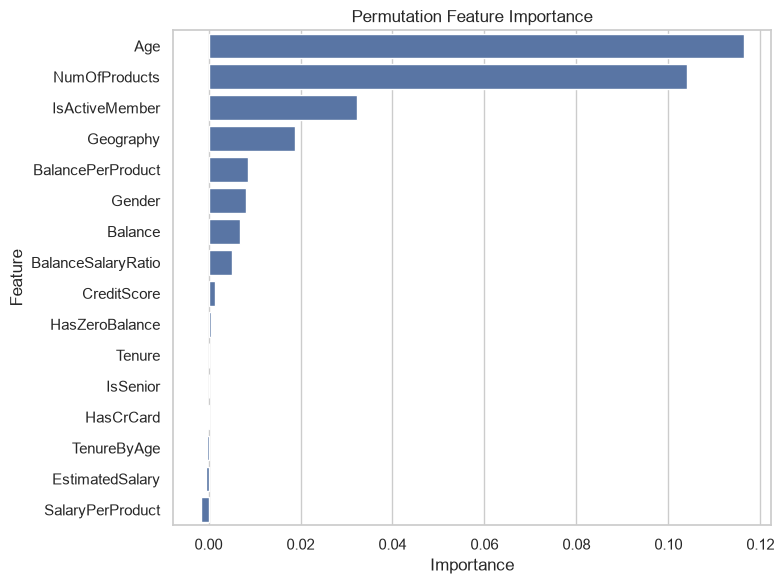

In [49]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    y="Feature",
    x="Importance"
)

plt.title(
    "Permutation Feature Importance"
)

plt.tight_layout()
plt.show()

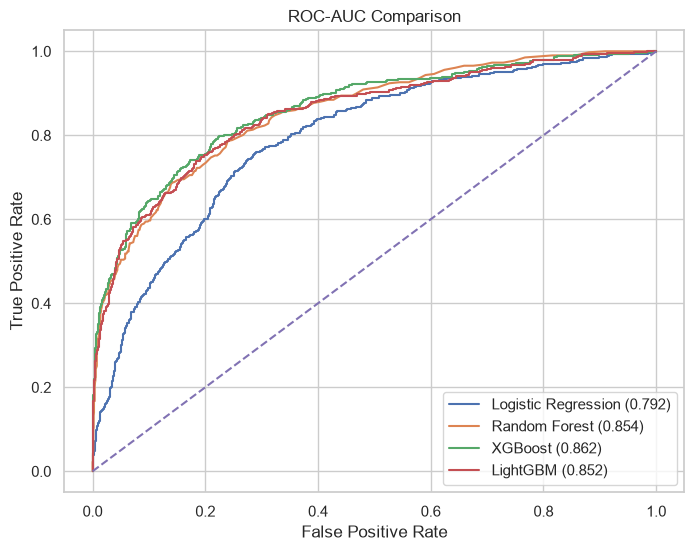

In [50]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    probability = model.predict_proba(
        X_test
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} ({auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.show()

In [51]:
import joblib

joblib.dump(
    best_xgb,
    "best_model.joblib"
)

['best_model.joblib']

In [52]:
ann.save(
    "keras_ann.keras"
)

In [53]:
joblib.dump(
    ann_preprocessor,
    "ann_preprocessor.joblib"
)

['ann_preprocessor.joblib']

In [54]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Production model:", best_model_name)
print("CV ROC-AUC:", cv_results.iloc[0]["CV ROC-AUC"])

joblib.dump(best_model, "best_model.joblib")

print("Best model saved as best_model.joblib")

Production model: XGBoost
CV ROC-AUC: 0.8658741127408962
Best model saved as best_model.joblib


In [55]:
ann.save("keras_ann.keras")
joblib.dump(ann_preprocessor, "ann_preprocessor.joblib")

['ann_preprocessor.joblib']

In [56]:
#load the pickle file
